In [1]:
import math
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

# Curve Computation

Compute two array of values, one for convex curves and another for concave. Both of these are so-called "positive" curves such that as X goes from 0 - 127, the Y value goes from 0 - 1.0. Additional "negative" and bipolar curves are built from these two arrays.

The SF2 specification for a "negative" concave curve gives the following pseudo-code:

```
output = -20/96 * log((value^2)/(range^2))
where value = input value - min value
      range = max value   – min value
```

The code below uses the same calculation though there is scaling to match other areas of the SF2 spec (namely attenuation in centiBels) and hoisting of operations outside of the loop. Also, the loop does not visit 0.0 since that would yield an exception in the call to `math.log10`.

In [14]:
peakAttenuation = -960.0
curveTableSize = 128

convexCurveTable = [0.0] * curveTableSize
convexCurveTable[curveTableSize - 1] = 1.0

concaveCurveTable = [0.0] * curveTableSize
concaveCurveTable[curveTableSize - 1] = 1.0

scale = 200.0 / peakAttenuation
denom = (curveTableSize - 1) * (curveTableSize - 1)
for index in range(1, curveTableSize - 1):
    x = scale * math.log10(float(index * index) / denom)
    convexCurveTable[index] = 1.0 - x
    concaveCurveTable[(curveTableSize - 1) - index] = x

def make_plot(title, x, y):
    fig = plt.figure()
    ax = fig.add_axes([0, 0, 1, 1])
    ax.grid()
    ax.plot(x, y)
    ax.set_box_aspect(1)
    ax.set_title(title)
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')

# Convex Plots

The Y value changes rapidly for low X values, reaching 0.5 when X is ~8. The rest of X to 127 is met with increasing Y but the intervals between subsequent values gets smaller.

### Positive Unipolar

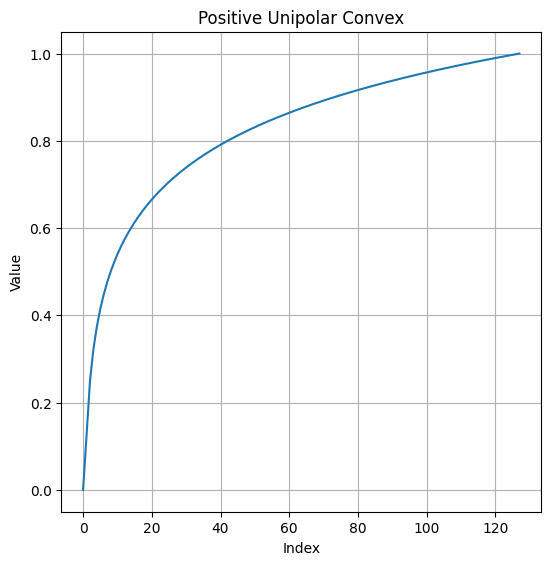

In [25]:
make_plot('Positive Unipolar Convex', np.arange(0, len(convexCurveTable)), np.array(convexCurveTable))

### Negative Unipolar

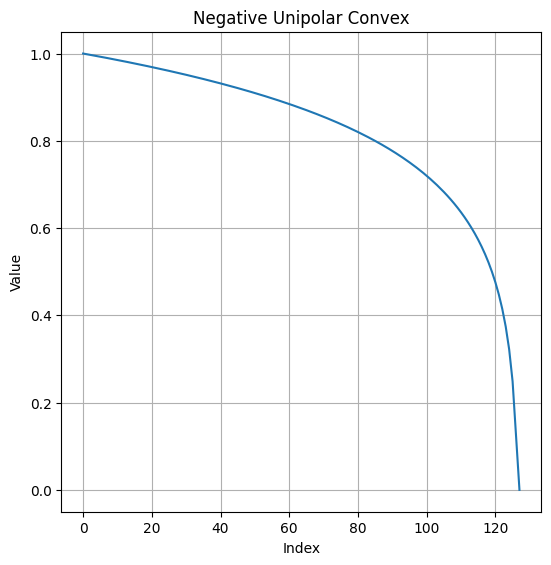

In [26]:
make_plot('Negative Unipolar Convex', np.arange(0, len(convexCurveTable)), np.array(convexCurveTable[::-1]))

### Positive Bipolar

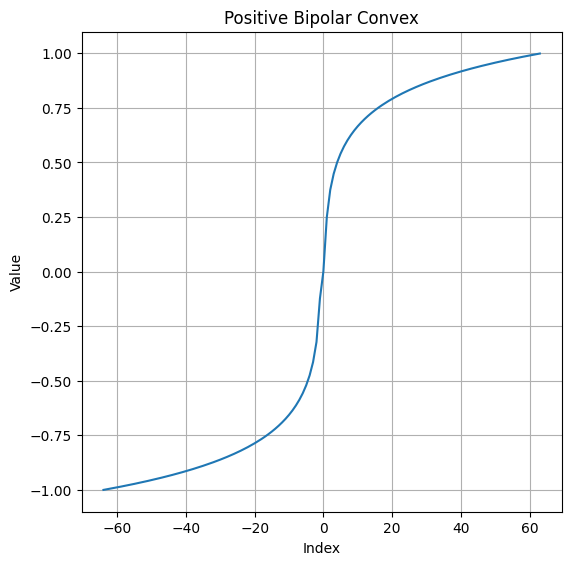

In [18]:
x = np.arange(-64, len(convexCurveTable) - 64)
y = np.concat((np.array(convexCurveTable[::-2]) * -1, np.array(convexCurveTable[::2])))
make_plot('Positive Bipolar Convex', x, y)

### Negative Bipolar

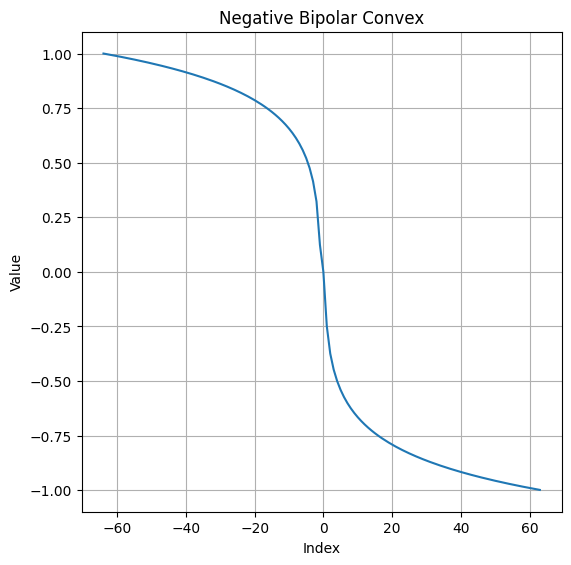

In [19]:
x = np.arange(-64, len(convexCurveTable) - 64)
y = np.concat((np.array(convexCurveTable[::-2]), np.array(convexCurveTable[::2]) * -1))
make_plot('Negative Bipolar Convex', x, y)

# Concave Plots

The Y grows in small incremental stesp over much of X until about 100 when Y adopts larger changes between subsequent values until it reaches 1.0.

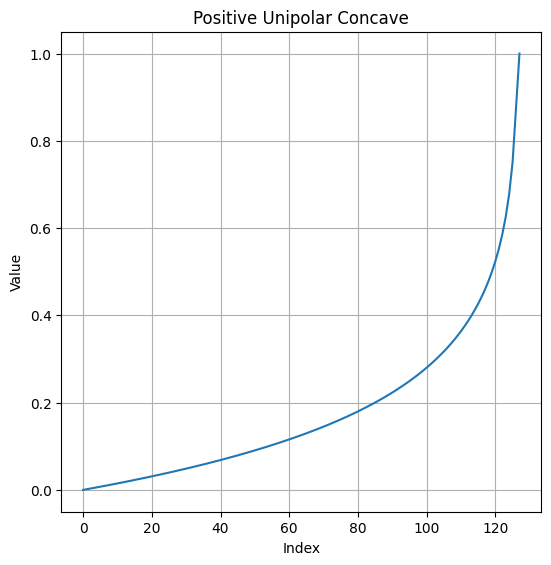

In [27]:
make_plot('Positive Unipolar Concave', np.arange(0, len(concaveCurveTable)), np.array(concaveCurveTable))

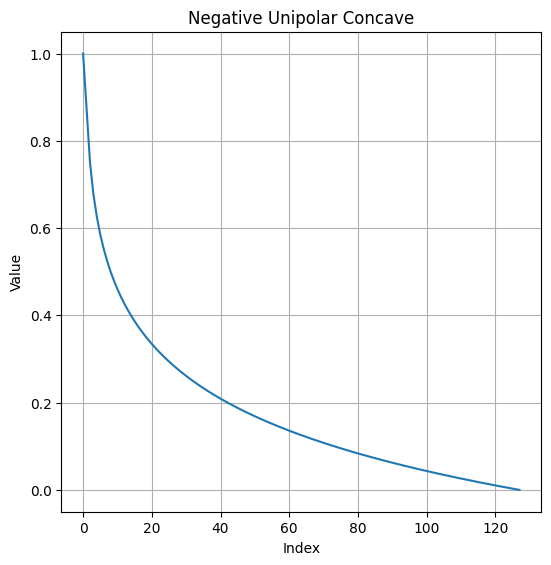

In [28]:
make_plot('Negative Unipolar Concave', np.arange(0, len(concaveCurveTable)), np.array(concaveCurveTable)[::-1])

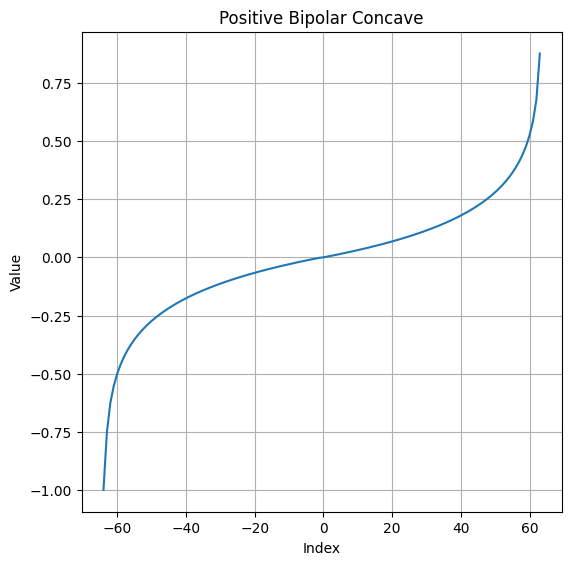

In [22]:
x = np.arange(-64, len(convexCurveTable) - 64)
y = np.concat((np.array(concaveCurveTable[::-2]) * -1, np.array(concaveCurveTable[::2])))
make_plot('Positive Bipolar Concave', x, y)

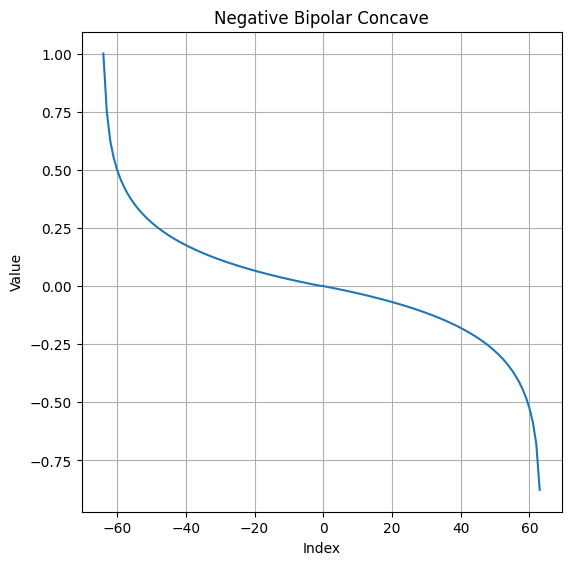

In [24]:
x = np.arange(-64, len(convexCurveTable) - 64)
y = np.concat((np.array(concaveCurveTable[::-2]), np.array(concaveCurveTable[::2]) * -1))
make_plot('Negative Bipolar Concave', x, y)